In [2]:
import pandas as pd
import os
import numpy as np
import os
pd.options.display.float_format = '{:.2f}'.format
# Get the current working directory
current_directory = os.getcwd()
print(current_directory)
# Parameter windowing
input_width = 48
label_width = 48
shift = label_width
total_window_size = input_width + shift
OUT_STEPS = label_width
# Definisikan irisan untuk input dan label
input_slice = slice(0, input_width)
label_start = total_window_size - label_width
labels_slice = slice(label_start, None)

def import_data(pathload, hari_khusus_saja=False):
    df_awal=pd.read_excel(pathload)
    #DROP KOLOM SUHU
    df_awal.drop(columns=['Keterangan', 'Keterangan.1'], inplace=True)
    df_awal.dropna(subset=['Beban'], inplace=True)
    df_awal['Hari_Khus'] = df_awal['Hari_Khus'].replace(13, 23)
    if hari_khusus_saja==True:
        return df_awal[df_awal['Hari_Khus']!=0].copy()
    else:
        return df_awal.copy()
    
    
def datetime_kolom(data, jumlah_hari, kelipatan_hari):
    df=data.copy()
    df['Date']=pd.to_datetime(df['Date'], format="%Y-%m-%d %H:%M:%S", dayfirst=True) #year-month-day(tanggal bukan hari)  H= hours, M=minutes, S= sekon 
    df['Tanggal']=df['Date'].dt.day
    df['Bulan']=df['Date'].dt.month
    df['Tahun']=df['Date'].dt.year
    df['Jam']=df['Date'].dt.hour
    df['Menit']=df['Date'].dt.minute
    
    df['Jam']=df['Jam']+df['Menit']/60 # agar setiap 30 menit menjadi 0.5 jam (contoh jam 13:30 menjadi 13.5)
    df.drop(columns=['Menit'], inplace=True)

    #1 hari = 48 (karena 30 menit), 1 bulan = 30 hari, 1 tahun =12 bulan
    mod_data= df['Beban'].count() % 48
    smpl_dta=df['Date'].count()-df['Beban'].count()+mod_data+(48*jumlah_hari*kelipatan_hari)
    df=df[-smpl_dta:]
    return df.copy()


def make_windows(data_x,data_y, total_window_size, input_slice, labels_slice):
    x = []
    y = []
    for i in range(len(data_x) - total_window_size + 1):
        window_x = data_x[i:i+total_window_size]
        x.append(window_x[input_slice])

    for i in range(len(data_y) - total_window_size + 1):
        window_y= data_y[i:i+total_window_size]
        y.append(window_y[labels_slice])

    return np.array(x), np.array(y)
def sin_cos_time(data):
    df= data.copy()
    df['Jam_sin'] = np.sin(df['Jam'] * (2 * np.pi / 24))
    df['Jam_cos'] = np.cos(df['Jam'] * (2 * np.pi / 24))
    df['Hari_sin'] = np.sin((df['Hari']-1) * (2 * np.pi / 7))
    df['Hari_cos'] = np.cos((df['Hari']-1) * (2 * np.pi / 7))
    df['Tanggal_sin'] = np.sin((df['Tanggal']-1) * (2 * np.pi / 30))
    df['Tanggal_cos'] = np.cos((df['Tanggal']-1) * (2 * np.pi / 30))
    df['Bulan_sin'] = np.sin((df['Bulan']-1) * (2 * np.pi / 12))
    df['Bulan_cos'] = np.cos((df['Bulan']-1) * (2 * np.pi / 12))
    
    #df['Hari_Khus_sin'] = np.sin((df['Hari_Khus']) * (2 * np.pi / 31))
    #df['Hari_Khus_cos']= np.cos((df['Hari_Khus']) * (2 * np.pi / 31))

    # mean_beban_per_jenis = df.groupby('Hari_Khus')['Beban'].mean()
    # # Hitung rata-rata beban global (keseluruhan data)
    # global_mean = df['Beban'].mean()

    # # Buat dictionary map: {Kode_Hari: Rasio_Impact}
    # # Contoh: Jika Hari 8 ratanya 17000 dan Global 25000, maka skornya 0.68 (turun 32%)
    # impact_map = mean_beban_per_jenis / global_mean

    # # Map ke kolom baru. Hari normal (0) akan memiliki nilai mendekati 1.0
    # df['Holiday_Impact'] = df['Hari_Khus'].map(impact_map)

    # # (Opsional) Jika ada kode baru di masa depan yang tidak ada di training, isi dengan 1.0 (Normal)
    # df['Holiday_Impact'] = df['Holiday_Impact'].fillna(1.0)

    # --- IMPLEMENTASI SMOOTHED MEAN ENCODING ---

    # 1. Hitung Rata-rata Global (Baseline)
    global_mean = df['Beban'].mean()

    # 2. Hitung Statistik per 'Hari_Khus' (Rata-rata DAN Jumlah Sampel)
    # Kita perlu tahu 'count' (berapa kali hari itu muncul)
    agregat = df.groupby('Hari_Khus')['Beban'].agg(['mean', 'count'])
    print(agregat  )
    # 3. Tentukan Faktor Smoothing 'm' (Weight)
    # Nilai m menentukan seberapa kuat kita "percaya" pada rata-rata global.
    # m = 10 adalah standar yang aman. Artinya: jika sampel < 10, nilai akan digeser mendekati global mean.
    m = 10

    # 4. Rumus Smoothed Mean
    # (n * category_mean + m * global_mean) / (n + m)
    smoothed_values = (
        (agregat['count'] * agregat['mean']) + (m * global_mean)
    ) / (agregat['count'] + m)

    # 5. Buat Dictionary Map: Rasio Smoothed Mean terhadap Global Mean
    impact_map = smoothed_values / global_mean

    # 6. Map ke kolom baru di DataFrame
    df['Holiday_Impact'] = df['Hari_Khus'].map(impact_map)

    # 7. Isi nilai yang kosong (jika ada kode baru di masa depan) dengan 1.0 (Normal)
    df['Holiday_Impact'] = df['Holiday_Impact'].fillna(1.0)
    return df.copy()
    

d:\satwika_bintang\CODE\TIMESERIES-master\1_pre


In [3]:
df_awal                         =   import_data(pathload='D:\\satwika_bintang\\CODE\\TIMESERIES-master\\Data_2025_10.xlsx', hari_khusus_saja=False)


In [4]:
df_awal

,Date,Bandung,Bekasi,Bogor,Cikarang,Cirebon,Denpasar,Gresik,Jakarta,Jember,...,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta,Hari,Hari_Khus,Beban
0,2022-01-01 00:30:00,19.90,24.80,23.70,24.50,24.55,23.65,25.40,24.95,23.75,...,24.80,24.50,24.80,22.80,25.15,25.15,22.70,6,2,18402.00
1,2022-01-01 01:00:00,19.90,24.50,23.50,24.20,24.40,23.50,25.20,24.80,23.60,...,25.70,24.40,24.50,22.60,25.00,25.10,22.50,6,2,18214.00
2,2022-01-01 01:30:00,20.00,24.40,23.30,24.05,24.05,23.75,24.90,24.70,23.55,...,25.05,24.15,24.20,22.60,24.90,25.00,22.45,6,2,17974.00
3,2022-01-01 02:00:00,20.10,24.30,23.10,23.90,23.70,24.00,24.60,24.60,23.50,...,24.40,23.90,23.90,22.60,24.80,24.90,22.40,6,2,17729.00
4,2022-01-01 02:30:00,19.50,24.15,22.90,23.80,24.35,24.15,24.55,24.55,23.35,...,24.10,23.95,24.00,22.60,24.80,24.65,22.20,6,2,17532.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,25.90,30.50,26.90,30.00,29.70,28.10,29.50,30.10,30.30,...,29.60,29.70,29.00,28.90,29.90,31.10,27.10,4,0,30957.80
67124,2025-10-30 10:30:00,26.50,31.15,27.40,30.55,30.15,28.35,29.70,30.75,30.70,...,29.70,30.25,29.45,29.10,30.60,31.65,27.20,4,0,30580.79
67125,2025-10-30 11:00:00,27.10,31.80,27.90,31.10,30.60,28.60,29.90,31.40,31.10,...,29.80,30.80,29.90,29.30,31.30,32.20,27.30,4,0,31497.36
67126,2025-10-30 11:30:00,27.35,32.15,28.15,31.65,30.95,28.70,30.05,31.85,31.30,...,29.95,31.25,30.10,29.45,31.75,32.65,27.35,4,0,31337.59


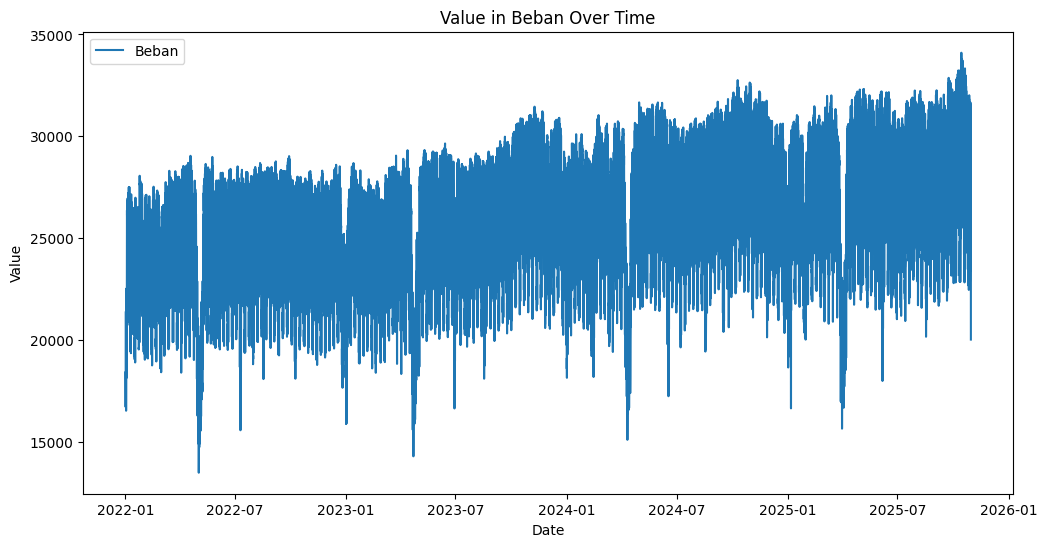

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert the Date column to datetime objects
df_awal['Date'] = pd.to_datetime(df_awal['Date'])

# 2. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_awal['Date'], df_awal['Beban'], label='Beban')

# 3. Add labels and title
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Value in Beban Over Time')
plt.legend()

# 4. Display the plot
plt.show()

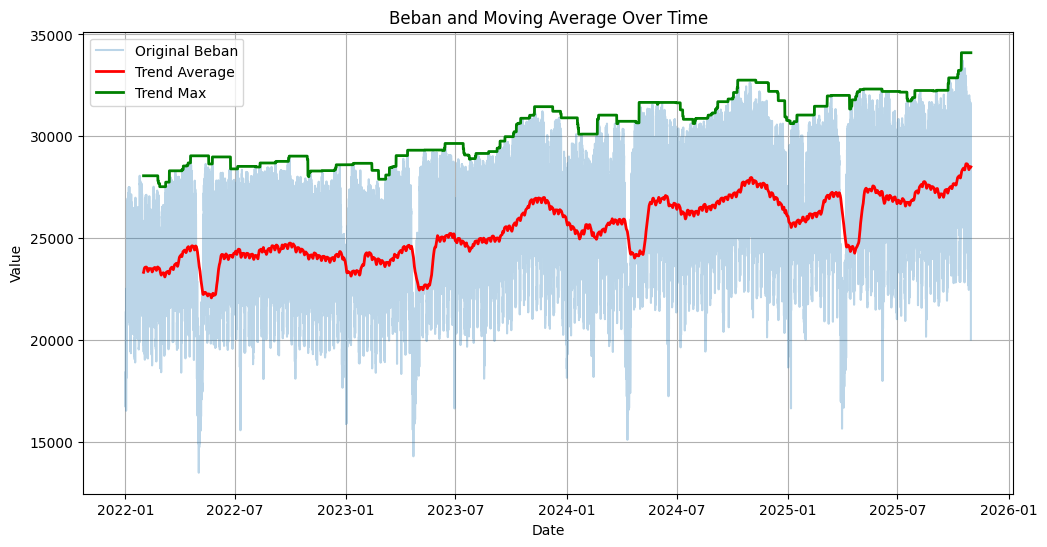

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert the Date column to datetime objects
df_awal['Date'] = pd.to_datetime(df_awal['Date'])

# 2. Calculate the moving average
# You can change the window size to adjust the smoothness
# A window of 48 points represents one day if data is recorded every 30 minutes
window_size = 48*30
df_awal['Beban_MA'] = df_awal['Beban'].rolling(window=window_size).mean()
df_awal['Beban_MAX'] = df_awal['Beban'].rolling(window=window_size).max()

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot the original data with transparency to make the trend clearer
plt.plot(df_awal['Date'], df_awal['Beban'], label='Original Beban', alpha=0.3)

# Plot the moving average with a solid color
plt.plot(df_awal['Date'], df_awal['Beban_MA'], label='Trend Average', color='red', linewidth=2)
plt.plot(df_awal['Date'], df_awal['Beban_MAX'], label='Trend Max', color='green', linewidth=2)
# 4. Add labels and title
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Beban and Moving Average Over Time')
plt.legend()
plt.grid(True)

# 5. Display the plot
plt.show()